Units passing criteria: 188
Units with a usable z_ccf: 143
Excluded for missing z_ccf: 45
Sessions represented before ACG loading: 34


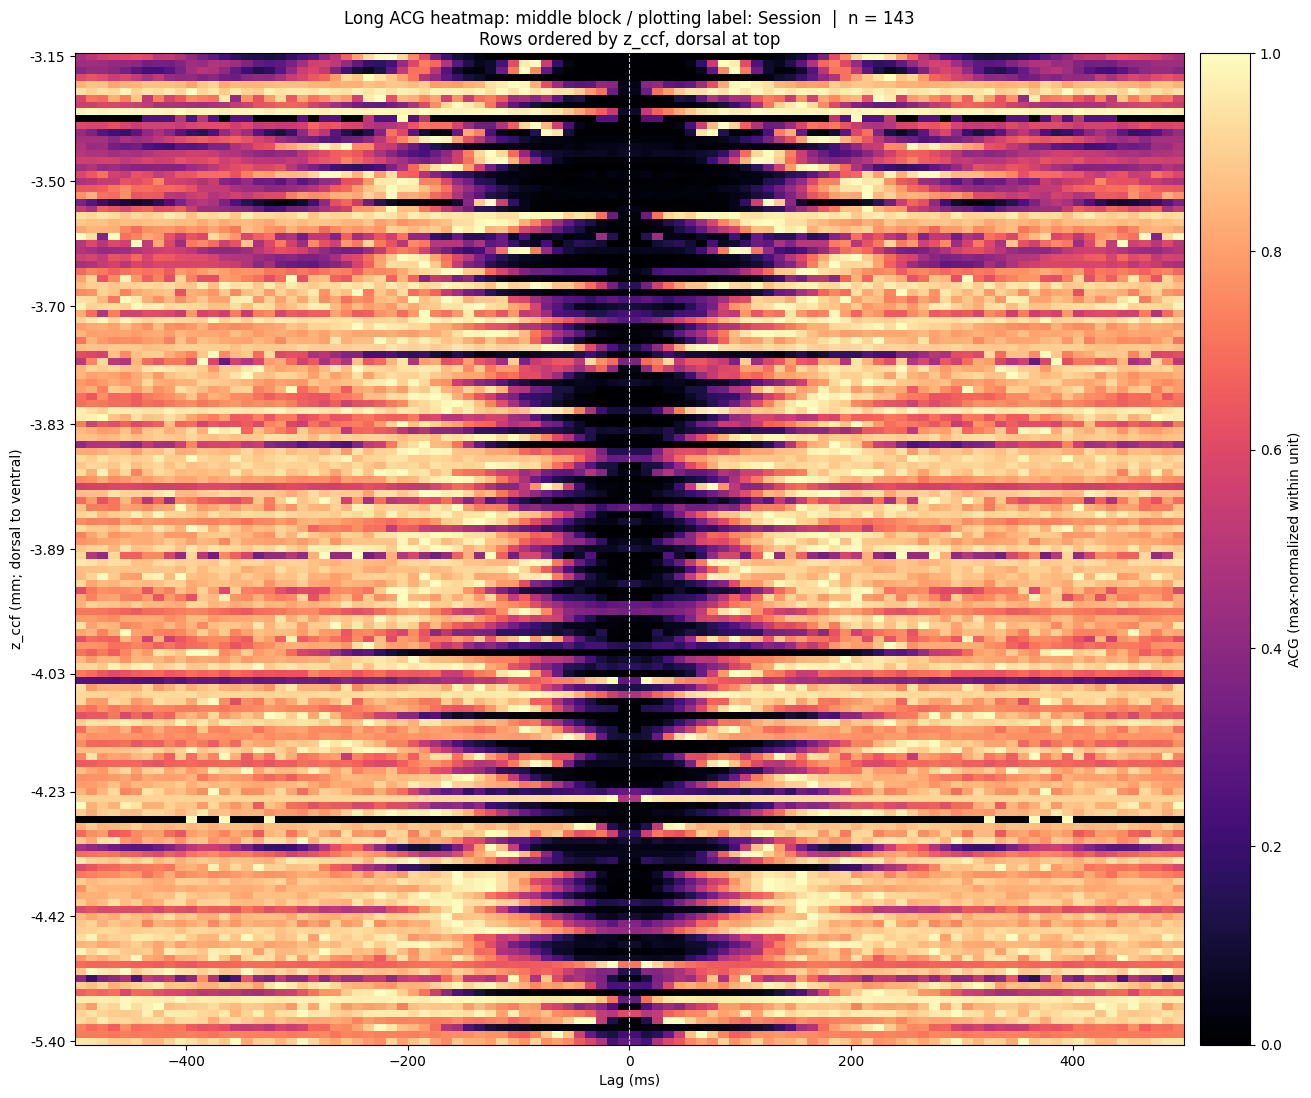

ACGs loaded into heatmap: 143
Saved lag grid: -500 to 500 ms; median bin width = 10 ms; 100 bins
Units skipped during ACG loading: 0
Rows interpolated to the reference time grid: 0
Segment meaning: spikes strictly between the last pre-opto onset and the first post-opto onset.

Row lookup (first 10):
 heatmap_row                             session  unit_id     z_ccf  mouse_id
           0 behavior_835444_2026-02-17_13-56-45      158 -3.153050    835444
           1 behavior_835444_2026-02-17_13-56-45      207 -3.242272    835444
           2 behavior_835444_2026-02-17_13-56-45      141 -3.255484    835444
           3 behavior_841596_2026-03-27_13-57-43      168 -3.283978    841596
           4 behavior_841861_2026-04-03_13-18-22       46 -3.320212    841861
           5 behavior_826159_2026-01-26_15-15-12       62 -3.343614    826159
           6 behavior_841861_2026-04-02_13-12-47       39 -3.357601    841861
           7 behavior_826164_2026-01-30_11-12-30       95 -3.361284    8261

In [4]:
# Notebook cell v2: long-ACG heatmap ordered by dorsal-ventral CCF coordinate
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support both repository layouts used in the preprocessing/plotting scripts.
for code_root in (
    '/root/capsule/code/beh_ephys_analysis',
):
    if code_root not in sys.path:
        sys.path.append(code_root)
from utils.beh_functions import session_dirs

# ----------------------------- knobs -----------------------------
MASTER_PATH = Path(
    '/root/capsule/scratch/combined/master_unit_tables/'
    'master_all_units_opto_ccf_raw_fix_260710_rebuilt_corr_from_metrics.csv'
)
DATA_TYPE = 'raw'

# Choose which saved diagonal ACG to display.
#
# IMPORTANT: these names refer to the block partition made by session_crosscorr:
#   nolaser = spikes BETWEEN the last pre-opto onset and first post-opto onset
#   laser   = spikes BEFORE/AT the last pre-opto onset OR AFTER/AT the first
#             post-opto onset
# They are not restricted to the milliseconds when the light is physically on.
# In opto_plotting_unit, nolaser is labeled 'Session' and laser is labeled 'Opto'.
ACG_STATE = 'nolaser'  # 'nolaser' or 'laser'

DV_COL = 'z_ccf'
DV_SORT_ASCENDING = False
# For these LPS-style CCF coordinates, z is DV-like and larger/less-negative
# values are more dorsal. False therefore places dorsal units at the top.

ROW_NORMALIZATION = 'max'  # 'max', 'zscore', 'sum', or 'none'
MASK_ZERO_LAG_MS = None     # e.g. 10.0 if the central 10-ms bin dominates
PLOT_LAG_RANGE_MS = None    # e.g. (-500, 500); None uses the full saved range
INTERPOLATE_MISMATCHED_TIME_GRIDS = True
COLOR_PERCENTILE = 99.5     # used for 'none' and 'zscore'
CMAP = None                 # None chooses automatically

CRITERIA = [
    'p_max >= 0.5',
    'lat_max_p >= 0.005',
    'lat_max_p <= 0.020',
    'corr_max_p >= 0.9',
    'isi_violations_ratio <= 0.1',
    'euc_max_p <= 0.4',
    'opto_pass == True',
    'default_qc == True',
]
# -----------------------------------------------------------------


def as_bool_series(series: pd.Series) -> pd.Series:
    """Robustly convert bool/string/0-1 CSV columns to bool."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    values = series.astype('string').str.strip().str.lower()
    mapped = values.map(
        {
            'true': True,
            '1': True,
            '1.0': True,
            'yes': True,
            'y': True,
            'false': False,
            '0': False,
            '0.0': False,
            'no': False,
            'n': False,
        }
    )
    return mapped.fillna(False).astype(bool)


def canonical_unit_id(value) -> str:
    """Make 22, 22.0, np.int64(22), and '22' compare identically."""
    try:
        number = float(value)
        if np.isfinite(number) and number.is_integer():
            return str(int(number))
    except (TypeError, ValueError):
        pass
    return str(value).strip()


def normalize_rows(matrix: np.ndarray, mode: str) -> np.ndarray:
    """Normalize each ACG independently so the heatmap emphasizes shape."""
    matrix = np.asarray(matrix, dtype=float)
    out = matrix.copy()

    if mode == 'none':
        return out

    if mode == 'max':
        scale = np.nanmax(out, axis=1)
        good = np.isfinite(scale) & (scale > 0)
        out[good] = out[good] / scale[good, None]
        out[~good] = 0.0
        return out

    if mode == 'sum':
        scale = np.nansum(out, axis=1)
        good = np.isfinite(scale) & (scale > 0)
        out[good] = out[good] / scale[good, None]
        out[~good] = 0.0
        return out

    if mode == 'zscore':
        mean = np.nanmean(out, axis=1, keepdims=True)
        std = np.nanstd(out, axis=1, keepdims=True)
        good = np.isfinite(std[:, 0]) & (std[:, 0] > 0)
        out[good] = (out[good] - mean[good]) / std[good]
        out[~good] = 0.0
        return out

    raise ValueError("ROW_NORMALIZATION must be 'max', 'zscore', 'sum', or 'none'.")


if ACG_STATE not in {'nolaser', 'laser'}:
    raise ValueError("ACG_STATE must be 'nolaser' or 'laser'.")

master = pd.read_csv(MASTER_PATH, low_memory=False)
SESSION_COL = 'session' if 'session' in master.columns else 'session_id'

required_columns = {
    SESSION_COL,
    'unit_id',
    DV_COL,
    'p_max',
    'lat_max_p',
    'corr_max_p',
    'isi_violations_ratio',
    'euc_max_p',
    'opto_pass',
    'default_qc',
}
missing_columns = sorted(required_columns.difference(master.columns))
if missing_columns:
    raise KeyError(f'Master table is missing required columns: {missing_columns}')

numeric_columns = [
    'unit_id',
    'p_max',
    'lat_max_p',
    'corr_max_p',
    'isi_violations_ratio',
    'euc_max_p',
    'x_ccf',
    'y_ccf',
    'z_ccf',
]
for column in numeric_columns:
    if column in master.columns:
        master[column] = pd.to_numeric(master[column], errors='coerce')

master['opto_pass'] = as_bool_series(master['opto_pass'])
master['default_qc'] = as_bool_series(master['default_qc'])

criteria_mask = pd.Series(True, index=master.index, dtype=bool)
for expression in CRITERIA:
    current = master.eval(expression, engine='python')
    criteria_mask &= pd.Series(current, index=master.index).fillna(False).astype(bool)

selected_all = master.loc[criteria_mask].copy()

# Only the dorsal-ventral coordinate is required for this ordering.
valid_ccf = selected_all[DV_COL].notna()
selected = selected_all.loc[valid_ccf].copy()

# Guarantee one heatmap row per unit.
if 'unit_uid' in selected.columns:
    dedup_columns = ['unit_uid']
else:
    dedup_columns = [SESSION_COL, 'unit_id']
number_of_duplicates = int(selected.duplicated(dedup_columns).sum())
if number_of_duplicates:
    print(f'Dropping {number_of_duplicates} duplicate unit rows using {dedup_columns}.')
    selected = selected.drop_duplicates(dedup_columns, keep='first')

selected = selected.sort_values(DV_COL, ascending=DV_SORT_ASCENDING).reset_index(drop=True)
selected['_requested_order'] = np.arange(len(selected), dtype=int)

print(f'Units passing criteria: {len(selected_all):,}')
print(f'Units with a usable {DV_COL}: {len(selected):,}')
print(f'Excluded for missing {DV_COL}: {len(selected_all) - len(selected):,}')
print(f'Sessions represented before ACG loading: {selected[SESSION_COL].nunique():,}')

loaded = []
skipped = []
reference_edges = None
reference_centers = None
interpolated_count = 0

id_key = f'unit_ids_{ACG_STATE}'
correlogram_key = f'correlogram_{ACG_STATE}'

# Load each session pickle once, then extract only diagonal entries [unit, unit, :].
for session, session_units in selected.groupby(SESSION_COL, sort=False):
    session = str(session)
    try:
        dirs = session_dirs(session)
        opto_dir = dirs[f'opto_dir_{DATA_TYPE}']
        acg_path = Path(opto_dir) / f'{session}_correlogram_laser_long.pkl'
    except Exception as exc:
        for _, row in session_units.iterrows():
            skipped.append(
                {
                    SESSION_COL: session,
                    'unit_id': row['unit_id'],
                    'reason': f'session_dirs failed: {exc}',
                }
            )
        continue

    if not acg_path.exists():
        for _, row in session_units.iterrows():
            skipped.append(
                {
                    SESSION_COL: session,
                    'unit_id': row['unit_id'],
                    'reason': 'missing long correlogram pickle',
                    'path': str(acg_path),
                }
            )
        continue

    try:
        with acg_path.open('rb') as stream:
            long_acg = pickle.load(stream)

        missing_keys = [
            key for key in ('time_bins', id_key, correlogram_key) if key not in long_acg
        ]
        if missing_keys:
            raise KeyError(f'missing keys {missing_keys}')

        edges = np.asarray(long_acg['time_bins'], dtype=float).reshape(-1)
        unit_ids = np.asarray(long_acg[id_key]).reshape(-1)
        correlograms = np.asarray(long_acg[correlogram_key])

        if correlograms.ndim != 3:
            raise ValueError(f'{correlogram_key} has shape {correlograms.shape}, expected 3-D')
        if correlograms.shape[:2] != (len(unit_ids), len(unit_ids)):
            raise ValueError(
                f'{correlogram_key} first two axes {correlograms.shape[:2]} '
                f'do not match {len(unit_ids)} unit IDs'
            )
        if len(edges) != correlograms.shape[2] + 1:
            raise ValueError(
                f'time_bins has {len(edges)} values but ACG has '
                f'{correlograms.shape[2]} bins; expected len(time_bins) = n_bins + 1'
            )

        centers = 0.5 * (edges[:-1] + edges[1:])
        if reference_edges is None:
            reference_edges = edges.copy()
            reference_centers = centers.copy()

        same_grid = (
            len(edges) == len(reference_edges)
            and np.allclose(edges, reference_edges, rtol=0, atol=1e-9)
        )

        id_to_index = {}
        for index, unit_id_from_pickle in enumerate(unit_ids):
            id_to_index.setdefault(canonical_unit_id(unit_id_from_pickle), index)

        for _, row in session_units.iterrows():
            unit_key = canonical_unit_id(row['unit_id'])
            unit_index = id_to_index.get(unit_key)
            if unit_index is None:
                skipped.append(
                    {
                        SESSION_COL: session,
                        'unit_id': row['unit_id'],
                        'reason': f'unit absent from {id_key}',
                        'path': str(acg_path),
                    }
                )
                continue

            acg = np.asarray(
                correlograms[unit_index, unit_index, :], dtype=float
            ).reshape(-1)

            interpolated = False
            if not same_grid:
                if not INTERPOLATE_MISMATCHED_TIME_GRIDS:
                    skipped.append(
                        {
                            SESSION_COL: session,
                            'unit_id': row['unit_id'],
                            'reason': 'time-bin grid differs from reference grid',
                            'path': str(acg_path),
                        }
                    )
                    continue
                acg = np.interp(
                    reference_centers,
                    centers,
                    acg,
                    left=np.nan,
                    right=np.nan,
                )
                interpolated = True
                interpolated_count += 1

            record = row.to_dict()
            record.update(
                {
                    'acg_path': str(acg_path),
                    'acg_state': ACG_STATE,
                    'time_grid_interpolated': interpolated,
                    '_acg': acg,
                }
            )
            loaded.append(record)

    except Exception as exc:
        for _, row in session_units.iterrows():
            skipped.append(
                {
                    SESSION_COL: session,
                    'unit_id': row['unit_id'],
                    'reason': f'could not read ACG pickle: {exc}',
                    'path': str(acg_path),
                }
            )

if not loaded:
    skipped_acgs = pd.DataFrame(skipped)
    raise RuntimeError(
        'No ACG rows were loaded. Inspect skipped_acgs and the printed paths/keys.'
    )

loaded.sort(key=lambda record: record['_requested_order'])
acg_matrix_raw = np.vstack([record.pop('_acg') for record in loaded])
acg_metadata = pd.DataFrame(loaded).reset_index(drop=True)
acg_metadata.insert(0, 'heatmap_row', np.arange(len(acg_metadata), dtype=int))

acg_time_edges_ms = reference_edges
acg_time_centers_ms = reference_centers
skipped_acgs = pd.DataFrame(skipped)

# Preserve raw values above; modify only the display copy below.
acg_matrix_display = acg_matrix_raw.copy()
if MASK_ZERO_LAG_MS is not None:
    center_mask = np.abs(acg_time_centers_ms) <= float(MASK_ZERO_LAG_MS)
    acg_matrix_display[:, center_mask] = np.nan

acg_matrix_display = normalize_rows(acg_matrix_display, ROW_NORMALIZATION)

# Color limits and colormap.
finite_values = acg_matrix_display[np.isfinite(acg_matrix_display)]
if finite_values.size == 0:
    raise RuntimeError('The loaded ACG matrix contains no finite values to plot.')

if ROW_NORMALIZATION in {'max', 'sum'}:
    vmin, vmax = 0.0, 1.0
    cmap = CMAP or 'magma'
    colorbar_label = f'ACG ({ROW_NORMALIZATION}-normalized within unit)'
elif ROW_NORMALIZATION == 'zscore':
    limit = float(np.nanpercentile(np.abs(finite_values), COLOR_PERCENTILE))
    limit = limit if np.isfinite(limit) and limit > 0 else 1.0
    vmin, vmax = -limit, limit
    cmap = CMAP or 'coolwarm'
    colorbar_label = 'ACG z-score within unit'
else:
    vmin = float(np.nanmin(finite_values))
    vmax = float(np.nanpercentile(finite_values, COLOR_PERCENTILE))
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = float(np.nanmax(finite_values))
    cmap = CMAP or 'magma'
    colorbar_label = 'Saved ACG value'

n_rows = len(acg_metadata)
figure_height = min(18.0, max(6.0, 3.0 + 0.055 * n_rows))
fig, ax = plt.subplots(figsize=(13, figure_height), constrained_layout=True)

image = ax.pcolormesh(
    acg_time_edges_ms,
    np.arange(n_rows + 1),
    acg_matrix_display,
    shading='flat',
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax.set_ylim(n_rows, 0)  # first sorted row at the top
ax.axvline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Lag (ms)')
ax.set_ylabel(f'{DV_COL} (mm; dorsal to ventral)')

if PLOT_LAG_RANGE_MS is not None:
    ax.set_xlim(*PLOT_LAG_RANGE_MS)

number_of_y_ticks = min(9, n_rows)
y_indices = np.unique(
    np.rint(np.linspace(0, n_rows - 1, number_of_y_ticks)).astype(int)
)
ax.set_yticks(y_indices + 0.5)
ax.set_yticklabels([f'{value:.2f}' for value in acg_metadata.loc[y_indices, DV_COL]])

state_label = (
    'middle block / plotting label: Session'
    if ACG_STATE == 'nolaser'
    else 'outer opto blocks / plotting label: Opto'
)
ax.set_title(
    f'Long ACG heatmap: {state_label}  |  n = {n_rows:,}\n'
    f'Rows ordered by {DV_COL}, dorsal at top'
)
colorbar = fig.colorbar(image, ax=ax, pad=0.015)
colorbar.set_label(colorbar_label)
plt.show()

saved_bin_widths = np.diff(acg_time_edges_ms)
print(f'ACGs loaded into heatmap: {n_rows:,}')
print(
    f'Saved lag grid: {acg_time_edges_ms[0]:g} to {acg_time_edges_ms[-1]:g} ms; '
    f'median bin width = {np.nanmedian(saved_bin_widths):g} ms; '
    f'{len(acg_time_centers_ms):,} bins'
)
print(f'Units skipped during ACG loading: {len(skipped_acgs):,}')
print(f'Rows interpolated to the reference time grid: {interpolated_count:,}')
if ACG_STATE == 'nolaser':
    print(
        'Segment meaning: spikes strictly between the last pre-opto onset and '
        'the first post-opto onset.'
    )
else:
    print(
        'Segment meaning: spikes in the broad outer pre/post opto blocks; '
        'not pulse-window-restricted.'
    )
if not skipped_acgs.empty:
    print('\nSkip reasons:')
    print(skipped_acgs['reason'].value_counts().to_string())

print('\nRow lookup (first 10):')
lookup_columns = [
    column
    for column in ('heatmap_row', SESSION_COL, 'unit_id', DV_COL, 'mouse_id')
    if column in acg_metadata.columns
]
print(acg_metadata[lookup_columns].head(10).to_string(index=False))

# Useful notebook outputs retained in memory:
#   selected_all       all units passing the criteria before the CCF requirement
#   selected           selected units with valid CCF, in requested DV order
#   acg_metadata       row-to-session/unit/CCF lookup for plotted ACGs
#   acg_matrix_raw     unnormalized saved ACG values
#   acg_matrix_display matrix actually shown in the heatmap
#   acg_time_edges_ms / acg_time_centers_ms
#   skipped_acgs       missing-file, missing-unit, or malformed-pickle diagnostics

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_metric_vs_z(
    table,
    metric,
    xlabel,
    dv_col="z_ccf",
    log_x=False,
    n_z_bins=8,
):
    """
    Plot one unit-level metric against its actual CCF z coordinate.

    Individual units are shown as points.
    The connected points are the median metric in z-coordinate bins.
    """
    p = table[[dv_col, metric]].copy()

    p[dv_col] = pd.to_numeric(p[dv_col], errors="coerce")
    p[metric] = pd.to_numeric(p[metric], errors="coerce")
    p = p.dropna()

    if log_x:
        p = p.loc[p[metric] > 0].copy()

    if p.empty:
        raise ValueError(f"No finite values available for {metric} versus {dv_col}.")

    fig, ax = plt.subplots(figsize=(5.5, 7))

    ax.scatter(
        p[metric],
        p[dv_col],
        s=25,
        alpha=0.65,
        label="Units",
    )

    # Optional binned median to make a broad DV trend easier to see.
    if n_z_bins is not None and n_z_bins > 1:
        z_edges = np.linspace(
            p[dv_col].min(),
            p[dv_col].max(),
            n_z_bins + 1,
        )

        p["_z_bin"] = pd.cut(
            p[dv_col],
            bins=z_edges,
            include_lowest=True,
        )

        binned = (
            p.groupby("_z_bin", observed=True)
            .agg(
                z_median=(dv_col, "median"),
                metric_median=(metric, "median"),
                n=(metric, "size"),
            )
            .dropna()
        )

        ax.plot(
            binned["metric_median"],
            binned["z_median"],
            marker="o",
            linewidth=2,
            label="Median within z bin",
        )

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"{dv_col} (mm)")
    ax.set_title(f"{xlabel} along the dorsal–ventral axis")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    # Do not invert the y-axis for your current coordinates:
    # larger / less-negative z_ccf is more dorsal and will naturally be higher.
    plt.tight_layout()
    plt.show()

    return p

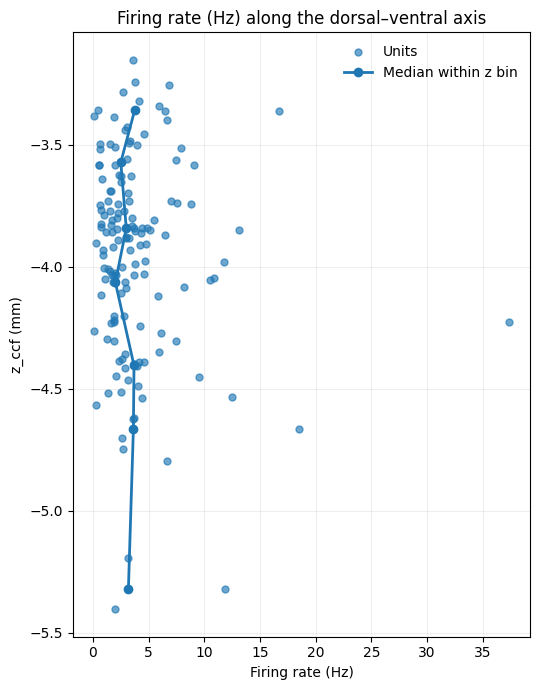

In [7]:
firing_rate_vs_z = plot_metric_vs_z(
    acg_metadata,
    metric="firing_rate",
    xlabel="Firing rate (Hz)",
    log_x=False,
    n_z_bins=8,
)

In [8]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd


# Neuropixels AP sampling rate.
# Change this if these templates were created at a different sampling rate.
WAVEFORM_SAMPLING_RATE_HZ = 30_000.0

# Do not search indefinitely after the trough for a late noisy peak.
MAX_AFTER_TROUGH_MS = 1.5


def unit_id_key(value):
    """Make 22, 22.0, np.int64(22), and '22' compare identically."""
    try:
        number = float(value)
        if np.isfinite(number) and number.is_integer():
            return str(int(number))
    except (TypeError, ValueError):
        pass

    return str(value).strip()


def trough_to_peak_width_ms(
    waveform,
    sampling_rate_hz=WAVEFORM_SAMPLING_RATE_HZ,
    max_after_trough_ms=MAX_AFTER_TROUGH_MS,
):
    """
    Measure negative-trough-to-following-peak duration in milliseconds.

    The search for the post-trough peak is restricted to
    max_after_trough_ms after the trough.
    """
    try:
        waveform = np.asarray(waveform, dtype=float).squeeze()
    except (TypeError, ValueError):
        return np.nan

    if waveform.ndim != 1 or waveform.size < 3:
        return np.nan

    if not np.isfinite(waveform).any():
        return np.nan

    trough_index = int(np.nanargmin(waveform))

    max_after_samples = int(
        np.ceil(max_after_trough_ms * sampling_rate_hz / 1000.0)
    )

    search_start = trough_index + 1
    search_stop = min(
        waveform.size,
        search_start + max_after_samples,
    )

    if search_stop <= search_start:
        return np.nan

    post_trough = waveform[search_start:search_stop]

    if not np.isfinite(post_trough).any():
        return np.nan

    peak_index = search_start + int(np.nanargmax(post_trough))

    width_ms = (
        (peak_index - trough_index)
        / sampling_rate_hz
        * 1000.0
    )

    if not np.isfinite(width_ms):
        return np.nan

    if width_ms <= 0 or width_ms > max_after_trough_ms:
        return np.nan

    return width_ms


SESSION_COL = (
    "session"
    if "session" in acg_metadata.columns
    else "session_id"
)

width_tables = []
width_failures = []

for session in acg_metadata[SESSION_COL].astype(str).unique():
    try:
        opto_dir = Path(
            session_dirs(session)[f"opto_dir_{DATA_TYPE}"]
        )

        waveform_path = (
            opto_dir
            / f"{session}_opto_waveform_metrics.pkl"
        )

        if not waveform_path.exists():
            width_failures.append(
                {
                    "session": session,
                    "reason": "missing opto waveform metrics pickle",
                    "path": str(waveform_path),
                }
            )
            continue

        with waveform_path.open("rb") as stream:
            waveform_table = pickle.load(stream)

        if not isinstance(waveform_table, pd.DataFrame):
            width_failures.append(
                {
                    "session": session,
                    "reason": (
                        "waveform pickle did not contain a pandas DataFrame"
                    ),
                    "path": str(waveform_path),
                }
            )
            continue

        required = {"unit_id", "spont", "peak_waveform"}
        missing = required.difference(waveform_table.columns)

        if missing:
            width_failures.append(
                {
                    "session": session,
                    "reason": f"missing columns: {sorted(missing)}",
                    "path": str(waveform_path),
                }
            )
            continue

        spontaneous = waveform_table.loc[
            pd.to_numeric(
                waveform_table["spont"],
                errors="coerce",
            ).eq(1)
        ].copy()

        spontaneous["_unit_key"] = spontaneous["unit_id"].map(
            unit_id_key
        )

        spontaneous["spike_width_ms"] = spontaneous[
            "peak_waveform"
        ].map(trough_to_peak_width_ms)

        # A unit can have spontaneous pre and spontaneous post templates.
        # Use their median width when both are available.
        per_unit_width = (
            spontaneous.groupby("_unit_key", as_index=False)
            .agg(
                spike_width_ms=("spike_width_ms", "median"),
                n_spontaneous_templates=(
                    "spike_width_ms",
                    "count",
                ),
            )
        )

        per_unit_width[SESSION_COL] = session
        width_tables.append(per_unit_width)

    except Exception as exc:
        width_failures.append(
            {
                "session": session,
                "reason": repr(exc),
            }
        )


if not width_tables:
    raise RuntimeError(
        "No spike widths were recovered. Inspect width_failures."
    )

spike_width_table = pd.concat(
    width_tables,
    ignore_index=True,
)

# Merge while preserving the existing ACG heatmap row order.
acg_metadata = acg_metadata.drop(
    columns=[
        "_unit_key",
        "spike_width_ms",
        "n_spontaneous_templates",
    ],
    errors="ignore",
).copy()

acg_metadata["_original_row_order"] = np.arange(
    len(acg_metadata)
)

acg_metadata[SESSION_COL] = (
    acg_metadata[SESSION_COL].astype(str)
)

acg_metadata["_unit_key"] = acg_metadata["unit_id"].map(
    unit_id_key
)

acg_metadata = (
    acg_metadata.merge(
        spike_width_table,
        on=[SESSION_COL, "_unit_key"],
        how="left",
        validate="many_to_one",
        sort=False,
    )
    .sort_values("_original_row_order")
    .drop(columns="_original_row_order")
    .reset_index(drop=True)
)

width_failures = pd.DataFrame(width_failures)

print(
    "Spike width recovered for "
    f"{acg_metadata['spike_width_ms'].notna().sum():,} / "
    f"{len(acg_metadata):,} heatmap units"
)

if not width_failures.empty:
    print("\nWidth-loading failures:")
    print(
        width_failures["reason"]
        .value_counts()
        .to_string()
    )

Spike width recovered for 143 / 143 heatmap units


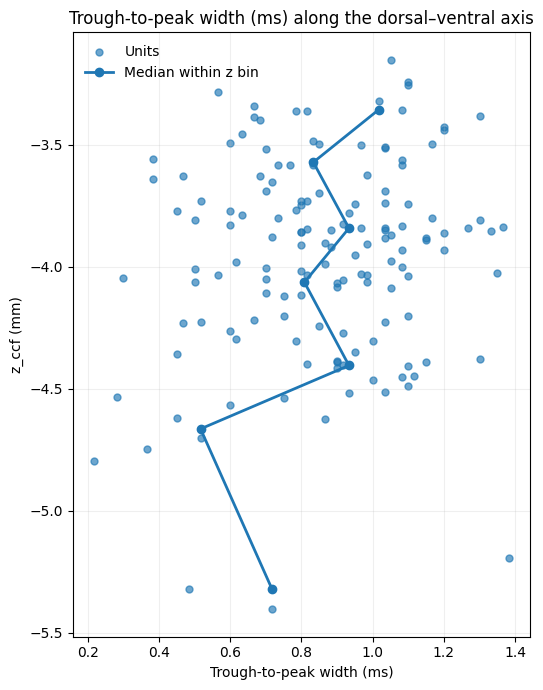

In [9]:
spike_width_vs_z = plot_metric_vs_z(
    acg_metadata,
    metric="spike_width_ms",
    xlabel="Trough-to-peak width (ms)",
    log_x=False,
    n_z_bins=8,
)